## Simple Linear Regression

# Ice Cream Sales Prediction using Simple Linear Regression

## Objective:
To analyze the relationship between temperature and ice cream sales and build a predictive model.

In [1]:
# Importing required libraries for data analysis and modeling
import pandas as pd
import numpy as np
from sklearn import linear_model
import matplotlib.pyplot as plt

In [2]:
# Loading dataset
df = pd.read_csv('icecream_sales.csv')

# Display first few rows
df.head()

,Temperature,Sales
0,15,200
1,18,300
2,20,400
3,22,500
4,24,600


## Exploratory Data Analysis (EDA)

- Checking relationship between temperature and sales
- Identifying trends and patterns

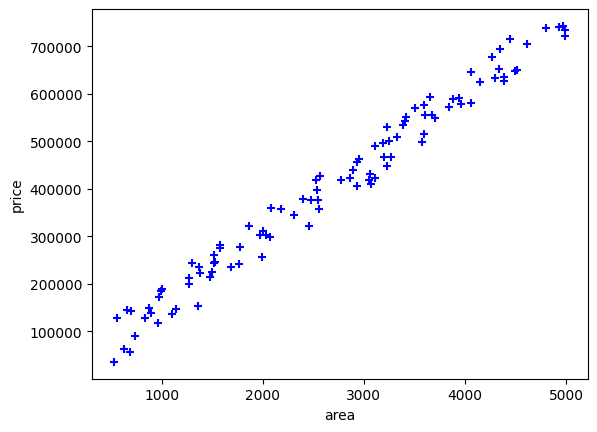

In [ ]:
# Scatter plot to visualize relationship
%matplotlib inline
plt.xlabel('area')
plt.ylabel('price')
plt.scatter(df.area,df.price,color='BLUE',marker='+')

In [ ]:
new_df = df.drop('price',axis='columns')
new_df

,area
0,1360
1,4272
2,3592
3,966
4,4926
...,...
95,1528
96,1002
97,4993
98,1370


In [ ]:
price = df.price
price

,price
0,154206
1,677854
2,576697
3,118319
4,739536
...,...
95,244933
96,189345
97,733648
98,236123


In [ ]:
# Create linear regression object
reg = linear_model.LinearRegression()
reg.fit(new_df,price)

LinearRegression()

**(1) Predict price of a home with area = 3300 sqr ft**

In [ ]:
reg.predict([[3300]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([497869.68175032])

In [ ]:
reg.coef_

array([148.27816676])

In [ ]:
reg.intercept_

np.float64(8551.731434376794)

**Y = m * X + b (m is coefficient and b is intercept)**

In [ ]:
148.27816676*3300+8551.731434376794

497869.6817423768

**(1) Predict price of a home with area = 5000 sqr ft**

In [ ]:
reg.predict([[5000]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([749942.56524642])

In [ ]:
148.27816676*5000+8551.731434376794

749942.5652343768

<h3 style="color:purple">Train Test Split</h3>

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
df

,area,price
0,1360,154206
1,4272,677854
2,3592,576697
3,966,118319
4,4926,739536
...,...,...
95,1528,244933
96,1002,189345
97,4993,733648
98,1370,236123


In [ ]:
X = df[['area']]
y = df['price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20)

In [ ]:
# Create linear regression object
reg = linear_model.LinearRegression()
reg.fit(X_train,y_train)

LinearRegression()

In [ ]:
y_pred = reg.predict(X_test)
y_pred

array([480568.1272033 , 224383.76706791, 552419.25094973, 268002.32867697,
       137146.6438498 , 652353.55819788, 114739.84850268, 435903.91514471,
       386758.3440167 , 540618.33873358, 198840.0203722 , 693731.44027222,
       362409.62640616, 108615.32444114, 386608.96538105,  88299.82999308,
       239471.00926831, 153727.67240667, 370774.83000242, 492966.55396204])

In [ ]:
# Print evaluation metrics
print("Coefficient (slope):", reg.coef_[0])
print("Intercept:", reg.intercept_)
print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R² Score:", r2_score(y_test, y_pred))

Coefficient (slope): 149.37863564745598
Intercept: 4050.2794879169087
MSE: 819267991.8905106
RMSE: 28622.85785679883
R² Score: 0.9743289031129797


R² = 1 → Perfect model (predictions match the data exactly).

R² close to 1 (like 0.9+) → Model explains most of the variance → very good fit.

R² ≈ 0 → Model explains almost nothing → basically guessing the mean of the target.

R² < 0 → Model is worse than just predicting the average every time (really bad).

### Observation:
There is a positive linear relationship between temperature and ice cream sales. 
As temperature increases, sales also increase.